In [2]:
import torch
import torch.nn as nn

import numpy as np

import brax
from brax import envs
from brax.envs import wrappers
import jax
import jax.numpy as jnp
import time
from tqdm import tqdm

# Create environment

device = 'cuda' if torch.cuda.is_available() else "cpu"
device



from IPython.display import clear_output
import matplotlib.pyplot as plt



from brax.io import torch as io_torch
from brax.envs.wrappers.training import VmapWrapper 
from dm_control import mujoco

import random

cpu_device = jax.devices("cpu")[0]
gpu_device = jax.devices("gpu")[0]


import jax
import jax.numpy as jnp
from brax import base
from brax.envs.base import PipelineEnv, State
from brax.io import mjcf


class Ant(PipelineEnv):

  # pyformat: enable


  def __init__(
      self,
      path,
      ctrl_cost_weight=0.5,
      use_contact_forces=False,
      contact_cost_weight=5e-4,
      healthy_reward=1.0,
      terminate_when_unhealthy=True,
      healthy_z_range=(0.2, 1.0),
      contact_force_range=(-1.0, 1.0),
      reset_noise_scale=0.0,
      exclude_current_positions_from_observation=True,
    #   backend='generalized',
      **kwargs,
  ):
      
    backend='mjx'
    # path = 'mazes/antmaze_hardest.xml'
    # path = 'mazes/ant.xml'
    sys = mjcf.load(path)

    n_frames = 5

    if backend in ['spring', 'positional']:
      sys = sys.tree_replace({'opt.timestep': 0.005})
      n_frames = 10

    if backend == 'mjx':
      sys = sys.tree_replace({
          'opt.solver': mujoco.mjtSolver.mjSOL_NEWTON,
          'opt.disableflags': mujoco.mjtDisableBit.mjDSBL_EULERDAMP,
          'opt.iterations': 4,
          'opt.ls_iterations': 4,
      })

    if backend == 'positional':
      # TODO: does the same actuator strength work as in spring
      sys = sys.replace(
          actuator=sys.actuator.replace(
              gear=200 * jnp.ones_like(sys.actuator.gear)
          )
      )

    kwargs['n_frames'] = kwargs.get('n_frames', n_frames)

    super().__init__(sys=sys, backend=backend, **kwargs)

    self._ctrl_cost_weight = ctrl_cost_weight
    self._use_contact_forces = use_contact_forces
    self._contact_cost_weight = contact_cost_weight
    self._healthy_reward = healthy_reward
    self._terminate_when_unhealthy = terminate_when_unhealthy
    self._healthy_z_range = healthy_z_range
    self._contact_force_range = contact_force_range
    self._reset_noise_scale = reset_noise_scale
    self._exclude_current_positions_from_observation = (
        exclude_current_positions_from_observation
    )

    if self._use_contact_forces:
      raise NotImplementedError('use_contact_forces not implemented.')
  
  def reset(self, rng: jax.Array) -> State:
    """Resets the environment to an initial state."""
    rng, rng1, rng2 = jax.random.split(rng, 3)

    low, hi = -self._reset_noise_scale, self._reset_noise_scale
    # q = self.sys.init_q + jax.random.uniform(
    #     rng1, (self.sys.q_size(),), minval=low, maxval=hi
    # )
    qpos = self.sys.init_q
    # print(qpos.shape)
    qpos = qpos.at[:2].set(jnp.array([2.5, 0.0]))
    qvel = hi * jax.random.normal(rng2, (self.sys.qd_size(),))

    pipeline_state = self.pipeline_init(qpos, qvel)
    obs = self._get_obs(pipeline_state)

    reward, done, zero = jnp.zeros(3)
    metrics = {
        'x_position': zero,
        'y_position': zero,
    }
    return State(pipeline_state, obs, reward, done, metrics)

  def step(self, state: State, action: jax.Array) -> State:
    """Run one timestep of the environment's dynamics."""
    pipeline_state0 = state.pipeline_state
    assert pipeline_state0 is not None
    pipeline_state = self.pipeline_step(pipeline_state0, action)

    obs = self._get_obs(pipeline_state)
    reward = 0
    
    state.metrics.update(
        x_position=pipeline_state.x.pos[0, 0],
        y_position=pipeline_state.x.pos[0, 1],
    )
    
    return state.replace(pipeline_state=pipeline_state, obs=obs, reward=reward)

  def _get_obs(self, pipeline_state: base.State) -> jax.Array:
    """Observe ant body position and velocities."""
    qpos = pipeline_state.q
    qvel = pipeline_state.qd
    
    # if self._exclude_current_positions_from_observation:
    #   qpos = pipeline_state.q[2:]
    # qpos = pipeline_state.x.pos[0, 0]
    
    # print(pipeline_state.x.pos[0, 0], pipeline_state.x.pos[0, 1])

    # return jnp.array([pipeline_state.x.pos[0, 0], pipeline_state.x.pos[0, 1]]) * STATE_SCALE
    return jnp.concatenate([qpos] + [qvel])

class TorchWrapper:
    def __init__(self, env, num_envs, state_dim=None):
        
        self.env = VmapWrapper(env, batch_size=num_envs)
        self.num_envs = num_envs
        self.state_dim = state_dim if state_dim is not None else env.observation_size
        self.action_dim = env.action_size
        
        
        # # JIT the reset and step functions
        # @jax.jit
        # def reset_fn(self, rng):
        #     return self.env.reset(rng)

        # @jax.jit
        # def step_fn(self, state, action):
        #     return self.env.step(state, action)
        
        self.reset_fn = jax.jit(self.env.reset)
        self.step_fn = jax.jit(self.env.step)
        
    
    def reset(self, seed=None):
        
        rng = jax.random.PRNGKey(random.randint(0, 99999999))
        state = self.reset_fn(rng)
        self.state = state
        return io_torch.jax_to_torch(state.obs), {}
    
    def step(self, action: torch.Tensor):
        
        action = io_torch.torch_to_jax(action)
        action = jax.device_put(action, gpu_device)
        next_state = self.step_fn(self.state, action)
        observation, reward, done = next_state.obs, next_state.reward, next_state.done
        
        self.state = next_state
                
        observation = io_torch.jax_to_torch(observation)
        reward = io_torch.jax_to_torch(reward)
        done = io_torch.jax_to_torch(done)
        
        info = {
            'x_coordinate': float(next_state.pipeline_state.x.pos[0, 0][0]),
            'y_coordinate': float(next_state.pipeline_state.x.pos[0, 1][0]),
        }
        
        
        self.state = next_state
        truncated = torch.full_like(done, fill_value=False)
        
        
        
        return observation.cpu(), reward.cpu(), done.cpu(), truncated.cpu(), info
        
        
        
        
def compute_gae_parallel(dones, rewards, values, next_values, gamma=0.99, lambda_=0.95):
    assert (
        dones.shape == rewards.shape == values.shape == next_values.shape
    ), "All inputs must have the same shape (num_envs, sequence_length)."

    num_envs, seq_len = dones.shape
    advantages = torch.zeros_like(rewards, dtype=torch.float32)
    returns = torch.zeros_like(rewards, dtype=torch.float32)
    last_advantage = torch.zeros(num_envs, dtype=torch.float32)
    last_return = torch.zeros(num_envs, dtype=torch.float32)

    for t in reversed(range(seq_len)):
        mask = 1.0 - dones[:, t]
        last_value = next_values[:, t] * mask
        last_advantage = last_advantage * mask
        last_return = last_return * mask

        delta = rewards[:, t] + gamma * last_value - values[:, t]
        last_advantage = delta + gamma * lambda_ * last_advantage
        last_return = rewards[:, t] + gamma * last_return

        advantages[:, t] = last_advantage
        returns[:, t] = last_return

    return advantages, returns


def post_process(action):
    # return torch.tanh(action)
    # return action
    return torch.clip(action, -1, 1)


def collect_trajectories(env, model, n_steps):

    # state_dim, action_dim = env.single_observation_space.shape[0], env.single_action_space.shape[0]
    state_dim, action_dim = env.state_dim, env.action_dim
    
    states = torch.zeros((env.num_envs, n_steps, state_dim), dtype=torch.float32)
    actions = torch.zeros((env.num_envs, n_steps, action_dim), dtype=torch.float32)
    rewards = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)
    log_ps = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)
    state_values = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)
    dones = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)

    healthy = torch.full((env.num_envs,), fill_value=True)
    
    state, _ = env.reset()
    
    # tensor([-2.2573,  0.2734])
    # state = torch.tensor([[-2.2573,  0.2734, 0., 0.]]).repeat(env.num_envs, 1)
    
    total_reward = 0
    step_count = 0
    
    # Just to get the dist:
    state = state.to(device)
    with torch.no_grad():
        _, _, _, dist, _ = model(state)
    
    rollout = []
    
    # for s in tqdm(range(n_steps)):
    for s in range(n_steps):
        # state = torch.tensor(state).to(device)
        state = state.to(device)
        
        if state.isnan().any():
            non_healthy_idx = state.isnan().any(dim=1).cpu()
            healthy[non_healthy_idx] = False
            # print(healthy)
            state[~healthy] = 0
        
        with torch.no_grad():

            action, log_p, state_value, dist, entropy = model(state)
                    
            
                    
            
        next_state, reward, terminated, truncated, info = env.step(post_process(action))
        done = terminated * truncated


        # gm_reward = state[..., 1].cpu() / 10
        # gm_reward = reward
        gm_reward = state[..., 0]
        # gm_reward = torch.zeros((env.num_envs,))
        
        states[:, s] = state
        actions[:, s] = action
        rewards[:, s] = gm_reward.reshape(-1)
        log_ps[:, s] = log_p
        state_values[:, s] = state_value.reshape(-1)
        dones[:, s] = done
        
        
        rollout.append((
            np.array(env.state.pipeline_state.x.pos),
            np.array(env.state.pipeline_state.x.rot),
            post_process(action)
        ))
        
        state = next_state
        
        # print(env.state.pipeline_state.x.pos[:, 0, 0], env.state.pipeline_state.x.pos[:, 0, 1])
            
    # rewards = torch.concat((torch.zeros((states.shape[0], 1), dtype=torch.float), (states[:, 1:, 0] - states[:, :-1, 0])), dim=1)

    
    next_value = model.critic(next_state.to(device)).cpu()
    next_state_values = torch.concatenate((state_values[:, 1:], next_value), dim=-1)
    
    advantages, returns = compute_gae_parallel(dones, rewards, state_values, next_state_values)
        
            
    trajectories = {
        # "descriptors": condition_descriptor.unsqueeze(1).repeat(1, n_steps, 1).reshape(-1, BEHAVIOR_DIM**2),
        "states" :  states.reshape(-1, state_dim).detach().cpu(),
        "actions" : actions.reshape(-1, action_dim).detach().cpu(),
        "rewards" : rewards.reshape(-1).detach().cpu(),
        "dones" : dones.reshape(-1).detach().cpu(),
        "log_ps" : log_ps.reshape(-1).detach().cpu(),
        "state_values": state_values.reshape(-1).detach().cpu(),
        "next_state_values": next_state_values.reshape(-1).detach().cpu(),
        "returns" : returns.reshape(-1).detach().cpu(),
        "advantages" : advantages.reshape(-1).detach().cpu(),
    }
    
    # Replace unhealthy trajectories with healthy trajectories:
    healthy_idx = healthy.int().argmax()
    # print((~healthy_idx).nonzero().flatten())
    for i in (~healthy_idx).nonzero().flatten():
        for key in trajectories:
            trajectories[key][i*200:(i+1)*200] = trajectories[key][healthy_idx*200:(healthy_idx+1)*200]
    
    return trajectories, {"rollout": rollout, "env.step:info": info}


# trajectories = collect_trajectories(env, model, n_steps=128)

# for key in trajectories:
#     print(key, trajectories[key].shape)

def shufffle_trajectory(trajectories):
    length = trajectories['states'].shape[0]
    permutation = torch.randperm(length)

    shuffled_trajectories = {key: tensor[permutation] for key, tensor in trajectories.items()}
    return shuffled_trajectories





def ppo_optimization(trajectories, model, optimizer, epochs, batch_size):
    
    model.train()
    
    traj_states = trajectories["states"]
    traj_actions = trajectories["actions"]
    traj_log_ps = trajectories["log_ps"]
    traj_returns = trajectories["returns"]  
    traj_advantages = trajectories["advantages"]


    len_trajectory = traj_states.shape[0]

    for epoch in range(1, epochs+1):
        for i in range(len_trajectory // batch_size):
            state = traj_states[batch_size*i:batch_size*(i+1)].to(device)
            action = traj_actions[batch_size*i:batch_size*(i+1)].to(device)
            log_p = traj_log_ps[batch_size*i:batch_size*(i+1)].to(device)
            return_ = traj_returns[batch_size*i:batch_size*(i+1)].to(device)
            advantage = traj_advantages[batch_size*i:batch_size*(i+1)].to(device)
            
            new_action, new_log_p, new_state_value, dist, entropy = model(state, action)
            assert(new_action == action).all()
            
            
            advantage = (advantage - advantage.mean()) / (advantage.std() + 1e-8)
                    
            new_log_p, log_p, advantage = new_log_p.reshape(-1), log_p.reshape(-1), advantage.reshape(-1)
            
            
            ratio = torch.exp(new_log_p - log_p.detach())
            surr1 = ratio * advantage
            surr2 = torch.clamp(ratio, 1-0.2, 1+0.2) * advantage
            policy_loss = - torch.min(surr1, surr2).mean()
            
            
            
            return_, new_state_value = return_.reshape(-1), new_state_value.reshape(-1)

            value_loss = ((return_ - new_state_value)**2).mean()

            ppo_loss = policy_loss - 1e-2*entropy.mean() + 0.5*value_loss

            
            loss = 1.*ppo_loss
            
            optimizer.zero_grad()
            loss.backward()
            clip_factor = torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
            
    # return entropy.mean().item(), policy_loss.item(), value_loss.item()
    return {
        'entropy': entropy.mean().item(),
        'policy_loss': policy_loss.item(),
        'value_loss': value_loss.item(),
        'ppo_loss': ppo_loss.item(),
        'loss': loss.item(),
    }
            
# ppo_optimization(trajectories, model, optimizer, epochs=1, batch_size=5)
# ppo_optimization(shuffled_trajectory, model, optimizer, epochs=5, batch_size=256)





class ActorCriticContinuous(nn.Module):
    def __init__(self, state_dim, action_dim, actor_hidden_layers, critic_hidden_layers, action_std=0.5, use_layernorm=False):
        super(ActorCriticContinuous, self).__init__()
        
        self.state_dim = state_dim
        self.action_dim = action_dim
        
        
        # Define actor network
        actor_layers = []
        input_dim = state_dim
        for hidden_dim in actor_hidden_layers:
            actor_layers.append(nn.Linear(input_dim, hidden_dim))
            if use_layernorm:
                actor_layers.append(nn.LayerNorm(hidden_dim))
            actor_layers.append(nn.ReLU())
            input_dim = hidden_dim
        actor_layers.append(nn.Linear(input_dim, action_dim))
        self.actor = nn.Sequential(*actor_layers)
        
        # Define critic network
        critic_layers = []
        input_dim = state_dim
        for hidden_dim in critic_hidden_layers:
            critic_layers.append(nn.Linear(input_dim, hidden_dim))
            if use_layernorm:
                actor_layers.append(nn.LayerNorm(hidden_dim))
            critic_layers.append(nn.ReLU())
            input_dim = hidden_dim
        critic_layers.append(nn.Linear(input_dim, 1))
        self.critic = nn.Sequential(*critic_layers)
        
        self.action_std = action_std
        self.action_var = nn.Parameter(torch.full((action_dim,), action_std**2, requires_grad=True))


    def forward(self, x, action=None):
        action_mean = self.actor(x)
        cov_matrix = torch.exp(self.action_var)
        dist = torch.distributions.Normal(loc=action_mean, scale=cov_matrix)
        
        if action is None:
            action = dist.sample()
            
        log_p = dist.log_prob(action).sum(dim=-1)
        
        value = self.critic(x)
        
        return action, log_p, value, dist, dist.entropy()
    
    
    
    
base_env = envs.get_environment('ant', backend='mjx', exclude_current_positions_from_observation=False, ctrl_cost_weight=0, healthy_reward=0, reset_noise_scale=0)
base_env = Ant('mazes/antmaze_empty.xml')

num_envs = 128
env = TorchWrapper(base_env, num_envs=num_envs)




model = ActorCriticContinuous(
    state_dim=env.state_dim,
    action_dim=env.action_dim,
    actor_hidden_layers=[512, 512],
    critic_hidden_layers=[512, 512]
).to(device)


optimizer = torch.optim.Adam(model.parameters(), lr=0.0002)

reward_list = []
final_coords_list = []





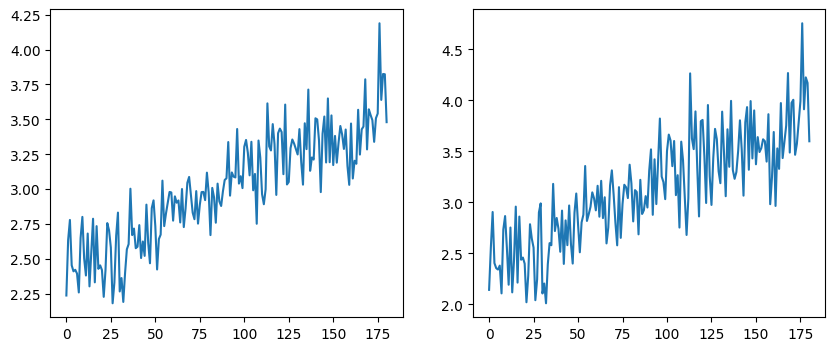

  2%|▏         | 188/10000 [10:13<8:53:48,  3.26s/it]


KeyboardInterrupt: 

In [3]:
EPISODE_LENGTH = 200

for i in tqdm(range(10000)):
    trajectory, info = collect_trajectories(env, model, n_steps=EPISODE_LENGTH)
    shuffled_trajectory = shufffle_trajectory(trajectory)
    
    ppo_optimization(shuffled_trajectory, model, optimizer, epochs=4, batch_size=1024)   
    
    avg_reward = trajectory['rewards'].mean().item()
    
    reward_list.append(avg_reward)
    final_coords_list.append(trajectory['states'].reshape(num_envs, EPISODE_LENGTH, 29)[:, -1, 0].mean().item())
    
    
    if i % 10 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        axs[0].plot(reward_list)
        axs[1].plot(final_coords_list)
        # plt.savefig(f"tmp/antmaze_simple_test_with_z.png")
        plt.show()